In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})


# Data

t_data = np.array([-2, -1, 0, 1, 2], dtype=float)
y_data = np.array([2, -10, 0, 2, 1], dtype=float)


# Build design matrix
# ----------------------------
def design_matrix(t, k):
    return np.column_stack([t**i for i in range(k + 1)])

# ----------------------------
# Least-squares objective
# J(x) = 0.5 * ||Ax - y||^2
def objective(x, A, y):
    r = A @ x - y
    return 0.5 * np.dot(r, r)

def gradient(x, A, y):
    return A.T @ (A @ x - y)

def hessian(A):
    return A.T @ A


# Newton's method for least squares

def newton_least_squares(A, y, x0=None, tol=1e-10, max_iter=20):
    n = A.shape[1]
    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.astype(float).copy()

    H = hessian(A)
    path = [x.copy()]
    costs = [objective(x, A, y)]

    for _ in range(max_iter):
        g = gradient(x, A, y)
        if np.linalg.norm(g) < tol:
            break

        p = -np.linalg.solve(H, g)
        x = x + p

        path.append(x.copy())
        costs.append(objective(x, A, y))

    return x, np.array(path), costs

# Quadratic fit: k = 2

k = 2
A = design_matrix(t_data, k)
x_opt, path, costs = newton_least_squares(A, y_data)

print("Optimization problem:")
print("Minimize J(x) = 0.5 * ||A x - y||^2")
print("Type: unconstrained convex quadratic least-squares problem\n")

print("Quadratic fit coefficients:")
print(f"x0 = {x_opt[0]:.6f}")
print(f"x1 = {x_opt[1]:.6f}")
print(f"x2 = {x_opt[2]:.6f}")

print("\nFitted polynomial:")
print(f"p(t) = {x_opt[0]:.6f} + ({x_opt[1]:.6f}) t + ({x_opt[2]:.6f}) t^2")

print("\nFinal least-squares cost =", objective(x_opt, A, y_data))
print("Iterations =", len(costs) - 1)

Optimization problem:
Minimize J(x) = 0.5 * ||A x - y||^2
Type: unconstrained convex quadratic least-squares problem

Quadratic fit coefficients:
x0 = -3.000000
x1 = 1.000000
x2 = 1.000000

Fitted polynomial:
p(t) = -3.000000 + (1.000000) t + (1.000000) t^2

Final least-squares cost = 40.0
Iterations = 1


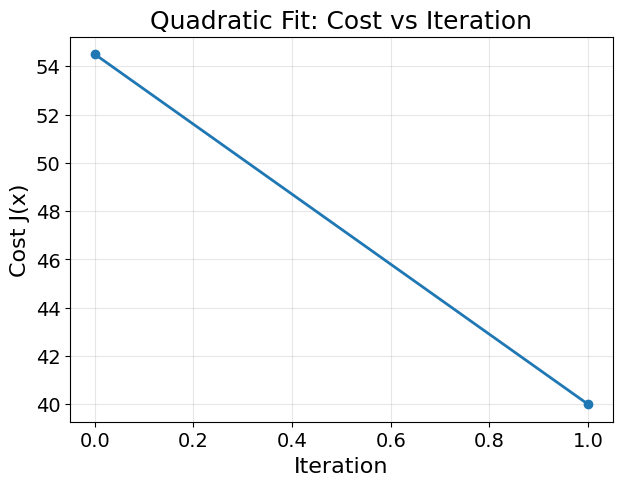

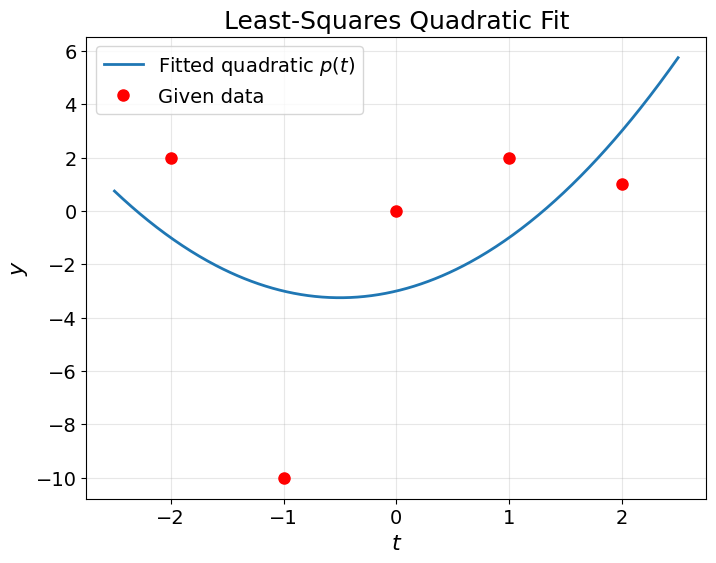

In [3]:
plt.figure(figsize=(7, 5))
plt.plot(range(len(costs)), costs, marker='o', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Cost J(x)")
plt.title("Quadratic Fit: Cost vs Iteration")
plt.grid(True, alpha=0.3)
plt.show()
def p(t, x):
    val = np.zeros_like(t, dtype=float)
    for i in range(len(x)):
        val += x[i] * t**i
    return val

t_plot = np.linspace(-2.5, 2.5, 400)
y_plot = p(t_plot, x_opt)

plt.figure(figsize=(8, 6))
plt.plot(t_plot, y_plot, linewidth=2, label='Fitted quadratic $p(t)$')
plt.plot(t_data, y_data, 'ro', markersize=8, label='Given data')
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Least-Squares Quadratic Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

k = 0: error = 104.000000
k = 1: error = 94.000000
k = 2: error = 80.000000
k = 3: error = 17.500000
k = 4: error = 0.000000


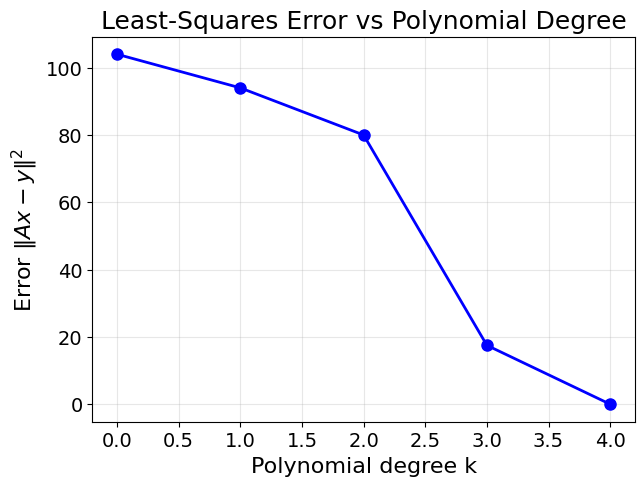

In [4]:
degrees = range(0, 5)   # with 5 data points, checking k = 0,1,2,3,4 is reasonable
errors = []

for k in degrees:
    A_k = design_matrix(t_data, k)
    x_k, _, _ = newton_least_squares(A_k, y_data)
    err = np.linalg.norm(A_k @ x_k - y_data)**2
    errors.append(err)

    print(f"k = {k}: error = {err:.6f}")

plt.figure(figsize=(7, 5))
plt.plot(list(degrees), errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Polynomial degree k")
plt.ylabel(r"Error $\|Ax-y\|^2$")
plt.title("Least-Squares Error vs Polynomial Degree")
plt.grid(True, alpha=0.3)
plt.show()

Degree-4 coefficients:
x0 = -0.000000
x1 = 8.083333
x2 = -5.458333
x3 = -2.083333
x4 = 1.458333
Squared error = 1.0598168836181181e-27


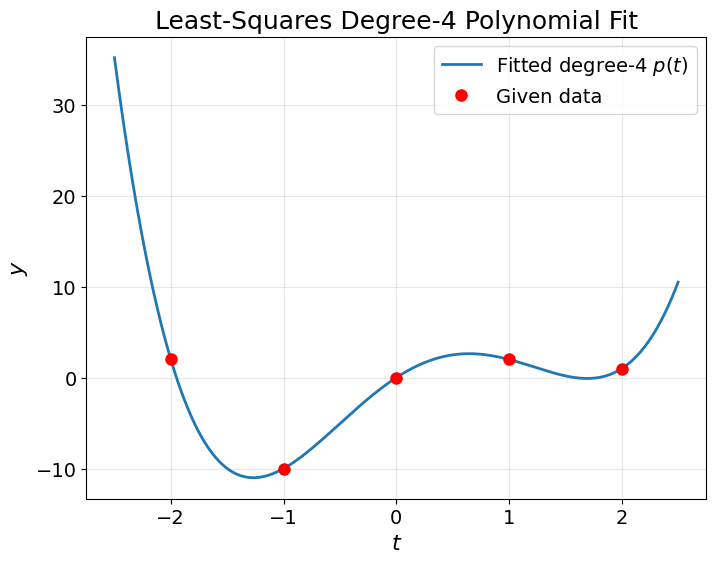

In [6]:
k = 4
A_k = design_matrix(t_data, k)
x_k, _, _ = newton_least_squares(A_k, y_data)

print("Degree-4 coefficients:")
for i, coeff in enumerate(x_k):
    print(f"x{i} = {coeff:.6f}")

print("Squared error =", np.linalg.norm(A_k @ x_k - y_data)**2)
def p(t, x):
    val = np.zeros_like(t, dtype=float)
    for i in range(len(x)):
        val += x[i] * t**i
    return val

t_plot = np.linspace(-2.5, 2.5, 500)
y_plot = p(t_plot, x_k)

plt.figure(figsize=(8, 6))
plt.plot(t_plot, y_plot, linewidth=2, label='Fitted degree-4 $p(t)$')
plt.plot(t_data, y_data, 'ro', markersize=8, label='Given data')
plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("Least-Squares Degree-4 Polynomial Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()